In [2]:
import nibabel as nib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
# Load the Nifti1Image 1
nifti1 = nib.load("./outputs/tBrainmap/tmap_beh60_p05.nii.gz")
# Convert the Nifti1Image object to a numpy array
data1 = nifti1.get_fdata()
array1 = data1.reshape(-1)

# Load the Nifti1Image 2
nifti2 = nib.load("./outputs/tBrainmap/tmap_gist_p01.nii.gz")
# Convert the Nifti1Image object to a numpy array
data2 = nifti2.get_fdata()
array2 = data2.reshape(-1)

In [29]:
mask1_greater = (array1 >= 2)
mask1_less = (array1 < 2) 
mask1_inf = np.isinf(array1)
masked_data1 = array1
masked_data1[:] = 0
masked_data1[mask1_inf] = 0
masked_data1[mask1_less] = 0
masked_data1[mask1_greater] = 1

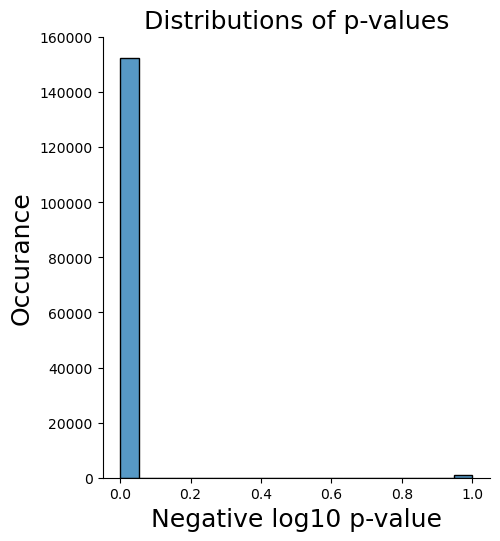

In [30]:
sns.displot(masked_data1)
plt.title('Distributions of p-values', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Negative log10 p-value', size=18)
plt.show()

In [31]:
mask2_greater = (array2 >= 2)
mask2_less = (array2 < 2) 
mask2_inf = np.isinf(array2)
masked_data2 = array2
masked_data2[:] = 0
masked_data2[mask2_inf] = 0
masked_data2[mask2_less] = 0
masked_data2[mask2_greater] = 1

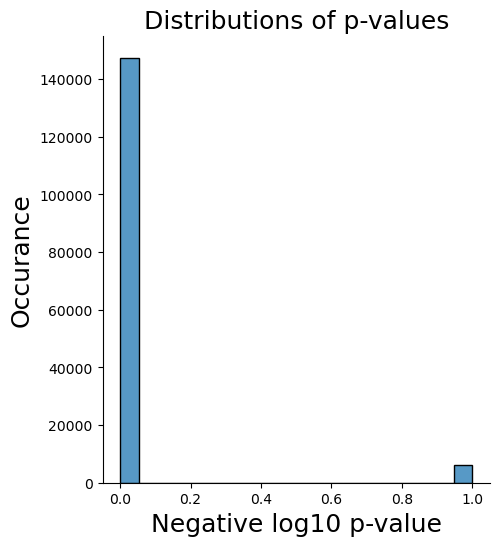

In [32]:
sns.displot(masked_data2)
plt.title('Distributions of p-values', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Negative log10 p-value', size=18)
plt.show()

In [48]:
index1 = np.array(np.where((data1.reshape(-1) >= 2) | (data1.reshape(-1) <= -2)))
index2 = np.array(np.where((data2.reshape(-1) >= 2) | (data2.reshape(-1) <= -2)))

In [49]:
# behavior
index1.shape

(1, 2598)

In [50]:
# gist
index2.shape

(1, 6280)

In [51]:
from scipy.spatial.distance import jaccard

In [52]:
dummy1 = data1.reshape(-1)
dummy1[:] = 0
dummy1[index1] = 1

dummy2 = data2.reshape(-1)
dummy2[:] = 0
dummy2[index2] = 1

In [53]:
# Calculate the Jaccard similarity coefficient
jaccard_similarity = 1 - jaccard(dummy1, dummy2)

# Print the Jaccard similarity coefficient
print(jaccard_similarity)

0.07912969490701349
